# DPL Tag Classifier — XGBoost vs LightGBM vs LinearSVC

Gradient boosting models (XGBoost, LightGBM) trained on TF-IDF + SVD features,  
compared head-to-head with the LinearSVC baseline.

| Model | Feature input | CPU training time (est.) |
|---|---|---|
| LinearSVC (baseline) | Sparse TF-IDF | < 10s |
| LightGBM | Sparse TF-IDF | ~30–120s |
| XGBoost | TF-IDF → SVD (dense) | ~60–300s |

> **Note:** For short structured text, linear models often outperform boosting.  
> This notebook lets you measure that gap on your actual data.

## Structure
1. Install & imports  
2. Load dataset & build features  
3. Baseline — LinearSVC  
4. LightGBM  
5. XGBoost  
6. Compare all three — accuracy, F1, speed  
7. Per-class F1 comparison  
8. Confidence scores  
9. Feature importance  
10. Save models  
11. Inference helper  

## 1. Install & Imports

In [1]:
%pip install -q xgboost lightgbm scikit-learn pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import json, os, time, warnings
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

import xgboost as xgb
import lightgbm as lgb

from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix,
)

import xgboost as xgb
import lightgbm as lgb

print(f"XGBoost  : {xgb.__version__}")
print(f"LightGBM : {lgb.__version__}")

XGBoost  : 3.2.0
LightGBM : 4.6.0


## 2. Load Dataset & Build Features

In [3]:
DATASETS_DIR = "datasets"
train_df    = pd.read_csv(f"{DATASETS_DIR}/dpl_train.csv")
val_df      = pd.read_csv(f"{DATASETS_DIR}/dpl_val.csv")
test_df     = pd.read_csv(f"{DATASETS_DIR}/dpl_test.csv")
trainval_df = pd.concat([train_df, val_df], ignore_index=True)

le = LabelEncoder()
le.fit(sorted(train_df["dpl_tag"].unique()))
NUM_CLASSES = len(le.classes_)

X_tv_raw   = trainval_df["description"].tolist()
y_tv       = le.transform(trainval_df["dpl_tag"])
X_test_raw = test_df["description"].tolist()
y_test     = le.transform(test_df["dpl_tag"])

print(f"Train+Val : {len(trainval_df):,}")
print(f"Test      : {len(test_df):,}")
print(f"Classes   : {NUM_CLASSES}")

Train+Val : 12,851
Test      : 2,272
Classes   : 76


In [4]:
# ── Shared TF-IDF vectoriser ─────────────────────────────────────────────────
# Word n-grams + character n-grams combined into one sparse matrix
tfidf = FeatureUnion([
    ("word", TfidfVectorizer(
        analyzer="word", ngram_range=(1, 3),
        min_df=2, max_features=50_000, sublinear_tf=True,
    )),
    ("char", TfidfVectorizer(
        analyzer="char_wb", ngram_range=(3, 5),
        min_df=3, max_features=30_000, sublinear_tf=True,
    )),
])

t0 = time.time()
X_tv_sparse   = tfidf.fit_transform(X_tv_raw)    # sparse matrix
X_test_sparse = tfidf.transform(X_test_raw)
print(f"TF-IDF fit+transform: {time.time()-t0:.1f}s")
print(f"Feature matrix shape: {X_tv_sparse.shape}")
print(f"Density: {X_tv_sparse.nnz / (X_tv_sparse.shape[0]*X_tv_sparse.shape[1]):.4%}")

TF-IDF fit+transform: 0.7s
Feature matrix shape: (12851, 26200)
Density: 0.3897%


In [5]:
# ── SVD (LSA) for XGBoost — reduces 80k sparse dims to 300 dense dims ────────
# XGBoost can use sparse matrices but convergence is better with dense SVD features
SVD_COMPONENTS = 300

t0 = time.time()
svd = TruncatedSVD(n_components=SVD_COMPONENTS, random_state=42)
X_tv_dense   = svd.fit_transform(X_tv_sparse)
X_test_dense = svd.transform(X_test_sparse)
print(f"SVD transform: {time.time()-t0:.1f}s")
print(f"Dense shape  : {X_tv_dense.shape}")
print(f"Explained variance: {svd.explained_variance_ratio_.sum():.2%}")

SVD transform: 8.3s
Dense shape  : (12851, 300)
Explained variance: 62.88%


## 3. Baseline — LinearSVC (Calibrated)

In [6]:
svc_pipe = Pipeline([
    ("clf", CalibratedClassifierCV(
        LinearSVC(C=1.0, max_iter=2000, dual="auto"),
        method="sigmoid", cv=3,
    )),
])

t0 = time.time()
svc_pipe.fit(X_tv_sparse, y_tv)
svc_time = time.time() - t0

svc_probs = svc_pipe.predict_proba(X_test_sparse)
svc_preds = svc_probs.argmax(axis=1)
svc_conf  = svc_probs.max(axis=1)

svc_acc = accuracy_score(y_test, svc_preds)
svc_f1  = f1_score(y_test, svc_preds, average="weighted", zero_division=0)
svc_mac = f1_score(y_test, svc_preds, average="macro",    zero_division=0)
print(f"LinearSVC — Time: {svc_time:>6.1f}s  Acc: {svc_acc:.4f}  "
      f"Weighted F1: {svc_f1:.4f}  Macro F1: {svc_mac:.4f}")

LinearSVC — Time:    5.4s  Acc: 0.9996  Weighted F1: 0.9996  Macro F1: 0.9996


## 4. LightGBM

LightGBM natively supports sparse TF-IDF matrices and is the fastest boosting option on CPU.

In [7]:
lgb_params = {
    "objective":       "multiclass",
    "num_class":       NUM_CLASSES,
    "metric":          "multi_logloss",
    "n_estimators":    500,
    "learning_rate":   0.1,
    "num_leaves":      63,
    "max_depth":       -1,          # unlimited depth controlled by num_leaves
    "min_child_samples": 5,
    "feature_fraction":  0.8,        # subsample columns per tree
    "bagging_fraction":  0.8,        # subsample rows per tree
    "bagging_freq":      5,
    "reg_alpha":         0.1,        # L1 regularisation
    "reg_lambda":        0.1,        # L2 regularisation
    "n_jobs":           -1,
    "verbose":          -1,
    "random_state":     42,
}

# Split a small validation set from trainval for early stopping
from sklearn.model_selection import train_test_split
X_lgb_tr, X_lgb_val, y_lgb_tr, y_lgb_val = train_test_split(
    X_tv_sparse, y_tv, test_size=0.1, stratify=y_tv, random_state=42
)

lgb_model = lgb.LGBMClassifier(**lgb_params)

t0 = time.time()
lgb_model.fit(
    X_lgb_tr, y_lgb_tr,
    eval_set=[(X_lgb_val, y_lgb_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=30, verbose=False),
        lgb.log_evaluation(period=50),
    ],
)
lgb_time = time.time() - t0

lgb_probs = lgb_model.predict_proba(X_test_sparse)  # (n, 76)
lgb_preds = lgb_probs.argmax(axis=1)
lgb_conf  = lgb_probs.max(axis=1)

lgb_acc = accuracy_score(y_test, lgb_preds)
lgb_f1  = f1_score(y_test, lgb_preds, average="weighted", zero_division=0)
lgb_mac = f1_score(y_test, lgb_preds, average="macro",    zero_division=0)
print(f"\nLightGBM  — Time: {lgb_time:>6.1f}s  Acc: {lgb_acc:.4f}  "
      f"Weighted F1: {lgb_f1:.4f}  Macro F1: {lgb_mac:.4f}")
print(f"Best iteration: {lgb_model.best_iteration_}")

[50]	valid_0's multi_logloss: 0.00790617
[100]	valid_0's multi_logloss: 0.00730798
[150]	valid_0's multi_logloss: 0.00716724
[200]	valid_0's multi_logloss: 0.0071047
[250]	valid_0's multi_logloss: 0.00707041
[300]	valid_0's multi_logloss: 0.00701649
[350]	valid_0's multi_logloss: 0.00696577
[400]	valid_0's multi_logloss: 0.00700565

LightGBM  — Time:  139.2s  Acc: 0.9974  Weighted F1: 0.9974  Macro F1: 0.9974
Best iteration: 370


## 5. XGBoost

XGBoost is trained on the dense SVD-reduced features (300 dimensions).

In [8]:
xgb_params = {
    "objective":        "multi:softprob",
    "num_class":        NUM_CLASSES,
    "eval_metric":      "mlogloss",
    "n_estimators":     500,
    "learning_rate":    0.1,
    "max_depth":        6,
    "min_child_weight": 3,
    "subsample":        0.8,
    "colsample_bytree": 0.8,
    "gamma":            0.1,
    "reg_alpha":        0.1,
    "reg_lambda":       1.0,
    "tree_method":      "hist",   # fastest CPU method
    "n_jobs":           -1,
    "random_state":     42,
    "verbosity":        0,
}

X_xgb_tr, X_xgb_val, y_xgb_tr, y_xgb_val = train_test_split(
    X_tv_dense, y_tv, test_size=0.1, stratify=y_tv, random_state=42
)

xgb_model = xgb.XGBClassifier(**xgb_params)

t0 = time.time()
xgb_model.fit(
    X_xgb_tr, y_xgb_tr,
    eval_set=[(X_xgb_val, y_xgb_val)],
    verbose=50,
)
xgb_time = time.time() - t0

xgb_probs = xgb_model.predict_proba(X_test_dense)   # (n, 76)
xgb_preds = xgb_probs.argmax(axis=1)
xgb_conf  = xgb_probs.max(axis=1)

xgb_acc = accuracy_score(y_test, xgb_preds)
xgb_f1  = f1_score(y_test, xgb_preds, average="weighted", zero_division=0)
xgb_mac = f1_score(y_test, xgb_preds, average="macro",    zero_division=0)
print(f"\nXGBoost   — Time: {xgb_time:>6.1f}s  Acc: {xgb_acc:.4f}  "
      f"Weighted F1: {xgb_f1:.4f}  Macro F1: {xgb_mac:.4f}")

[0]	validation_0-mlogloss:3.22912
[50]	validation_0-mlogloss:0.12766
[100]	validation_0-mlogloss:0.05805
[150]	validation_0-mlogloss:0.05176
[200]	validation_0-mlogloss:0.05062
[250]	validation_0-mlogloss:0.05029
[300]	validation_0-mlogloss:0.05017
[350]	validation_0-mlogloss:0.05011
[400]	validation_0-mlogloss:0.05004
[450]	validation_0-mlogloss:0.04998
[499]	validation_0-mlogloss:0.04993

XGBoost   — Time:  136.5s  Acc: 0.9947  Weighted F1: 0.9947  Macro F1: 0.9947


## 6. Compare All Three

           Accuracy  Weighted F1  Macro F1  Train time (s)  Mean confidence
Model                                                                      
LinearSVC    0.9996       0.9996    0.9996          5.4000           0.9777
LightGBM     0.9974       0.9974    0.9974        139.2000           0.9943
XGBoost      0.9947       0.9947    0.9947        136.5000           0.9668


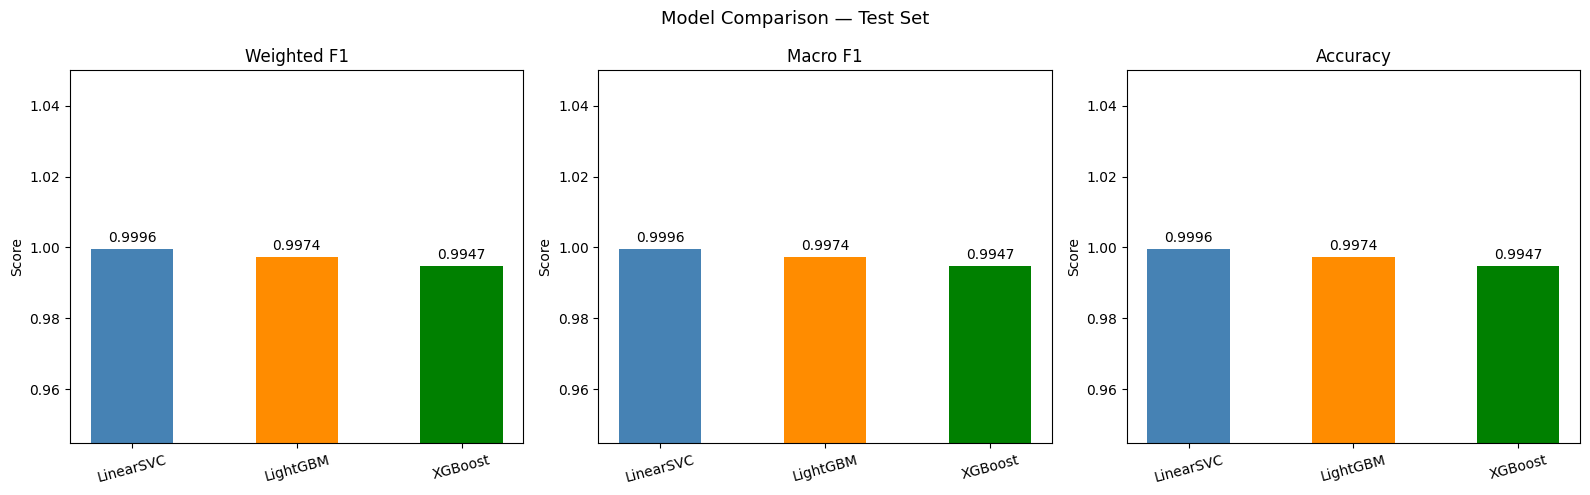

In [9]:
results = {
    "LinearSVC": {"acc": svc_acc, "f1w": svc_f1, "f1m": svc_mac,
                  "time": svc_time, "probs": svc_probs, "preds": svc_preds, "conf": svc_conf},
    "LightGBM":  {"acc": lgb_acc, "f1w": lgb_f1, "f1m": lgb_mac,
                  "time": lgb_time, "probs": lgb_probs, "preds": lgb_preds, "conf": lgb_conf},
    "XGBoost":   {"acc": xgb_acc, "f1w": xgb_f1, "f1m": xgb_mac,
                  "time": xgb_time, "probs": xgb_probs, "preds": xgb_preds, "conf": xgb_conf},
}

summary = pd.DataFrame([
    {"Model": k, "Accuracy": v["acc"], "Weighted F1": v["f1w"],
     "Macro F1": v["f1m"], "Train time (s)": round(v["time"], 1),
     "Mean confidence": round(v["conf"].mean(), 4)}
    for k, v in results.items()
]).set_index("Model")

print(summary.to_string(float_format="{:.4f}".format))

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ["steelblue", "darkorange", "green"]

for ax, (metric, title) in zip(axes, [
    ("Weighted F1", "Weighted F1"),
    ("Macro F1",    "Macro F1"),
    ("Accuracy",   "Accuracy"),
]):
    bars = ax.bar(summary.index, summary[metric], color=colors, width=0.5)
    ax.bar_label(bars, fmt="%.4f", padding=3)
    ax.set_ylim(max(0, summary[metric].min() - 0.05), 1.05)
    ax.set_title(title)
    ax.set_ylabel("Score")
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Model Comparison — Test Set", fontsize=13)
plt.tight_layout()
plt.show()

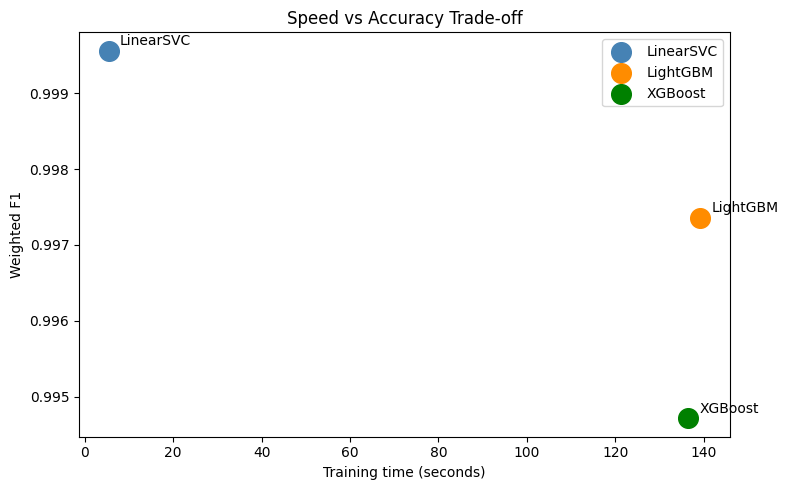

In [10]:
# Speed vs accuracy scatter
fig, ax = plt.subplots(figsize=(8, 5))
for name, color in zip(results, colors):
    ax.scatter(results[name]["time"], results[name]["f1w"],
               s=200, color=color, label=name, zorder=5)
    ax.annotate(name,
                (results[name]["time"], results[name]["f1w"]),
                xytext=(8, 4), textcoords="offset points", fontsize=10)
ax.set_xlabel("Training time (seconds)")
ax.set_ylabel("Weighted F1")
ax.set_title("Speed vs Accuracy Trade-off")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Per-class F1 Comparison

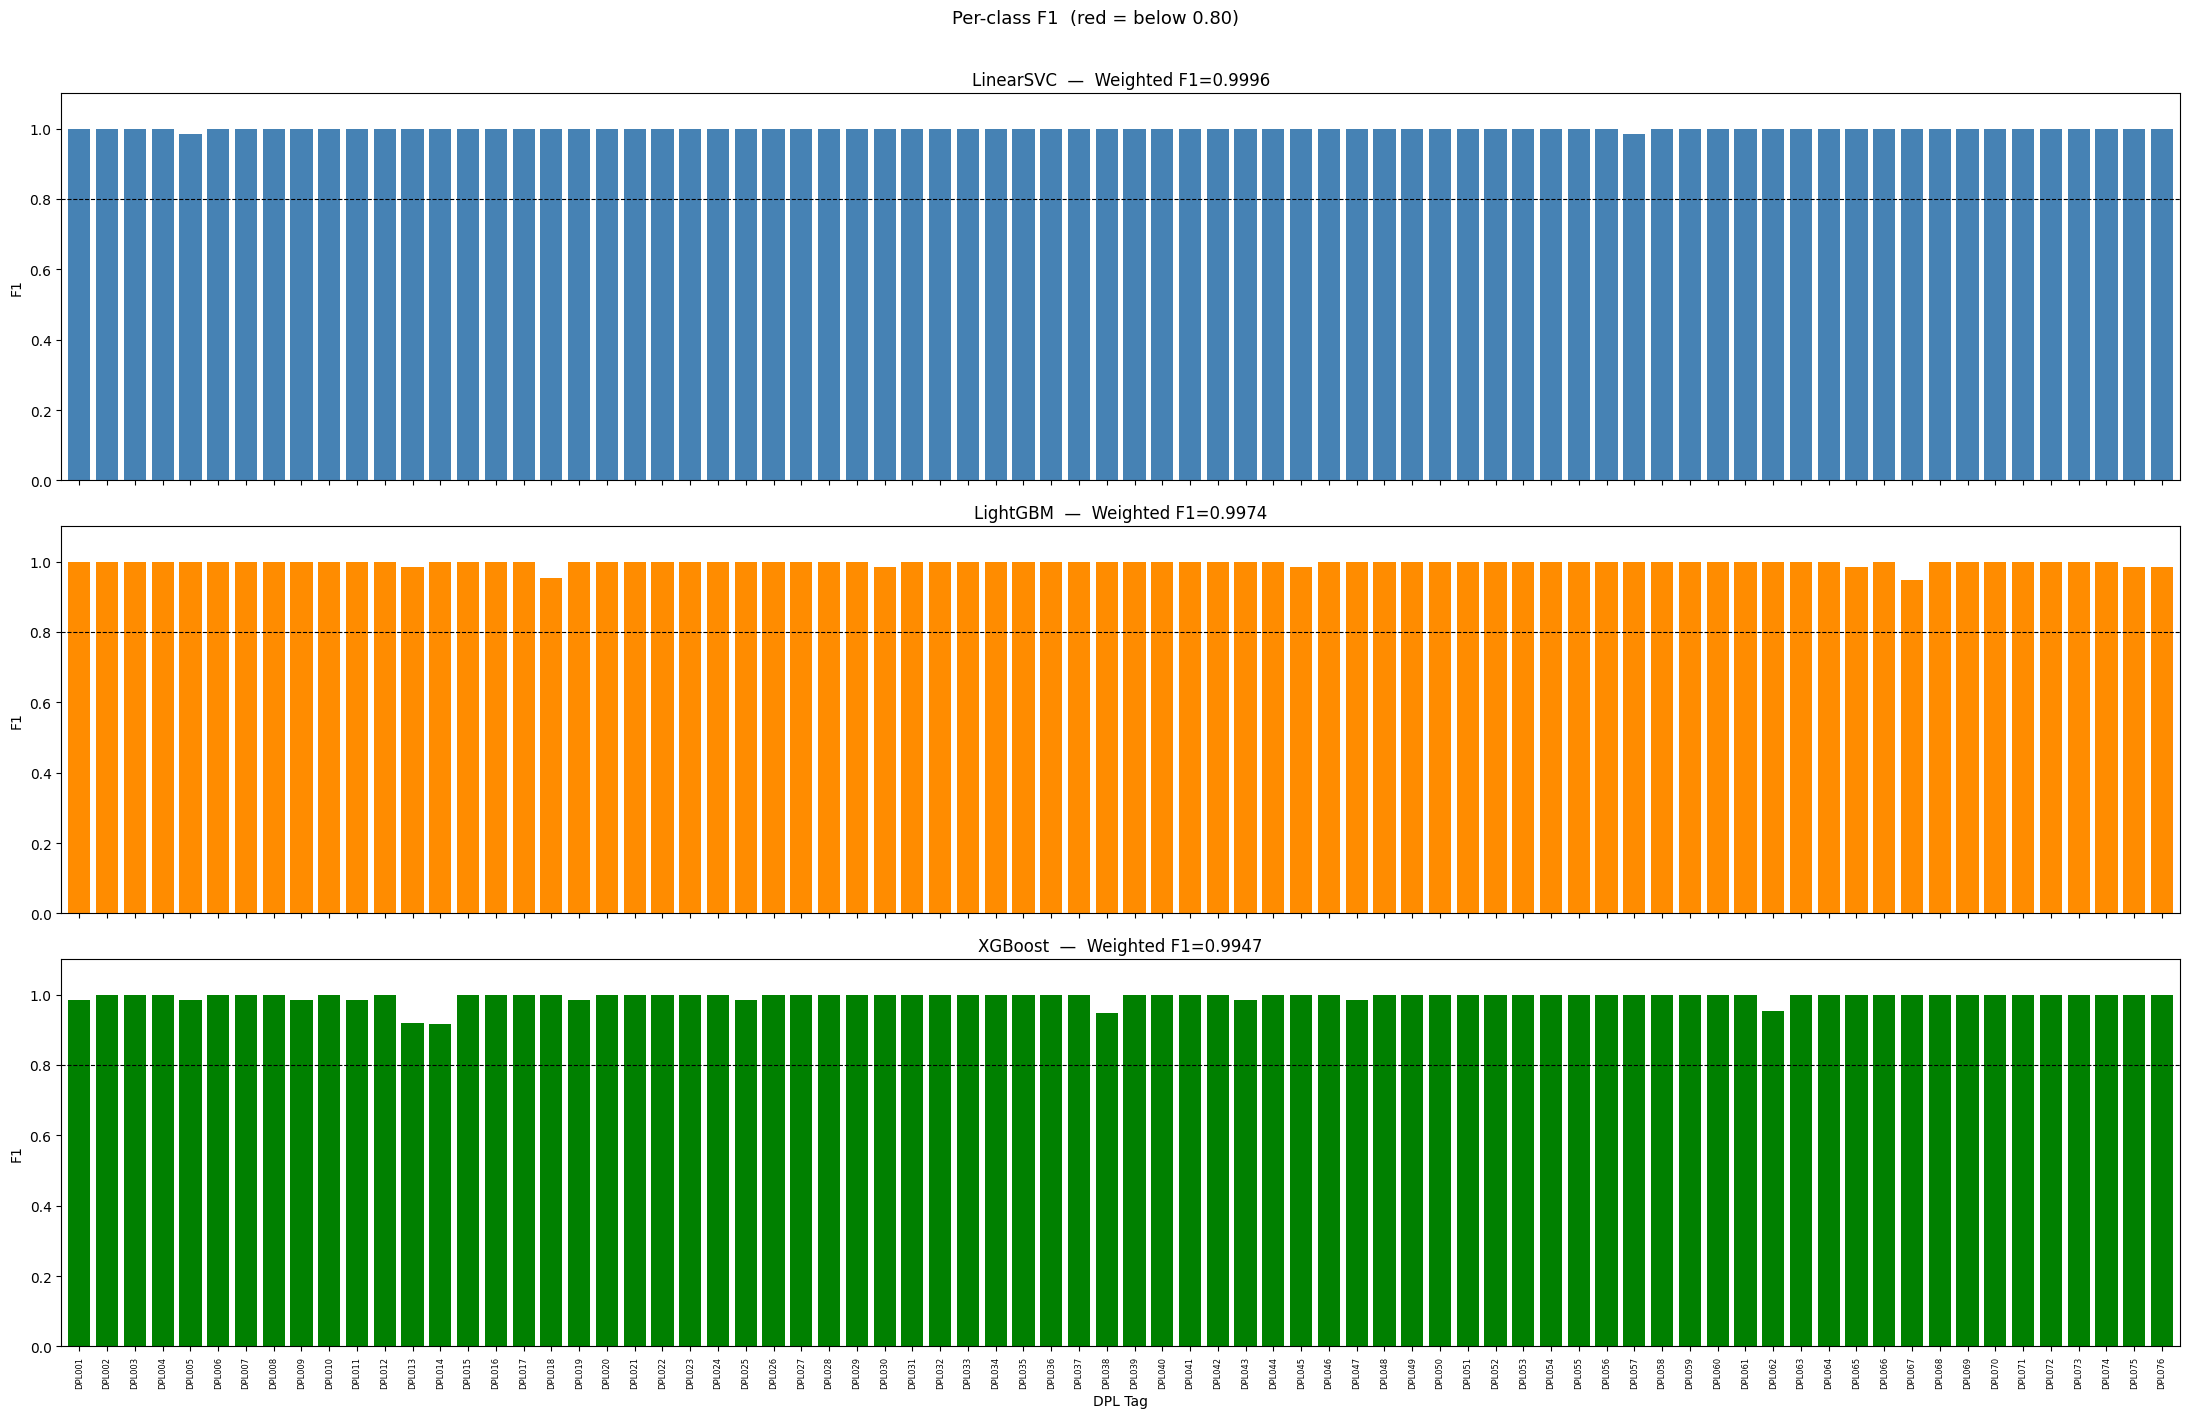

In [11]:
tag_names = le.classes_.tolist()
true_labels = le.inverse_transform(y_test)

per_class = {}
for name, v in results.items():
    rep = classification_report(
        true_labels,
        le.inverse_transform(v["preds"]),
        output_dict=True, zero_division=0,
    )
    per_class[name] = pd.Series(
        {t: rep[t]["f1-score"] for t in tag_names if t in rep}
    ).sort_index()

fig, axes = plt.subplots(3, 1, figsize=(22, 14), sharex=True)
for ax, (name, f1s), color in zip(axes, per_class.items(), colors):
    bar_colors = ["#d62728" if v < 0.80 else color for v in f1s.values]
    f1s.plot(kind="bar", ax=ax, color=bar_colors, width=0.8)
    ax.axhline(0.80, color="black", linestyle="--", linewidth=0.8)
    ax.set_title(f"{name}  —  Weighted F1={results[name]['f1w']:.4f}")
    ax.set_ylabel("F1")
    ax.set_ylim(0, 1.1)
    ax.tick_params(axis="x", labelsize=6)

axes[-1].set_xlabel("DPL Tag")
plt.suptitle("Per-class F1  (red = below 0.80)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

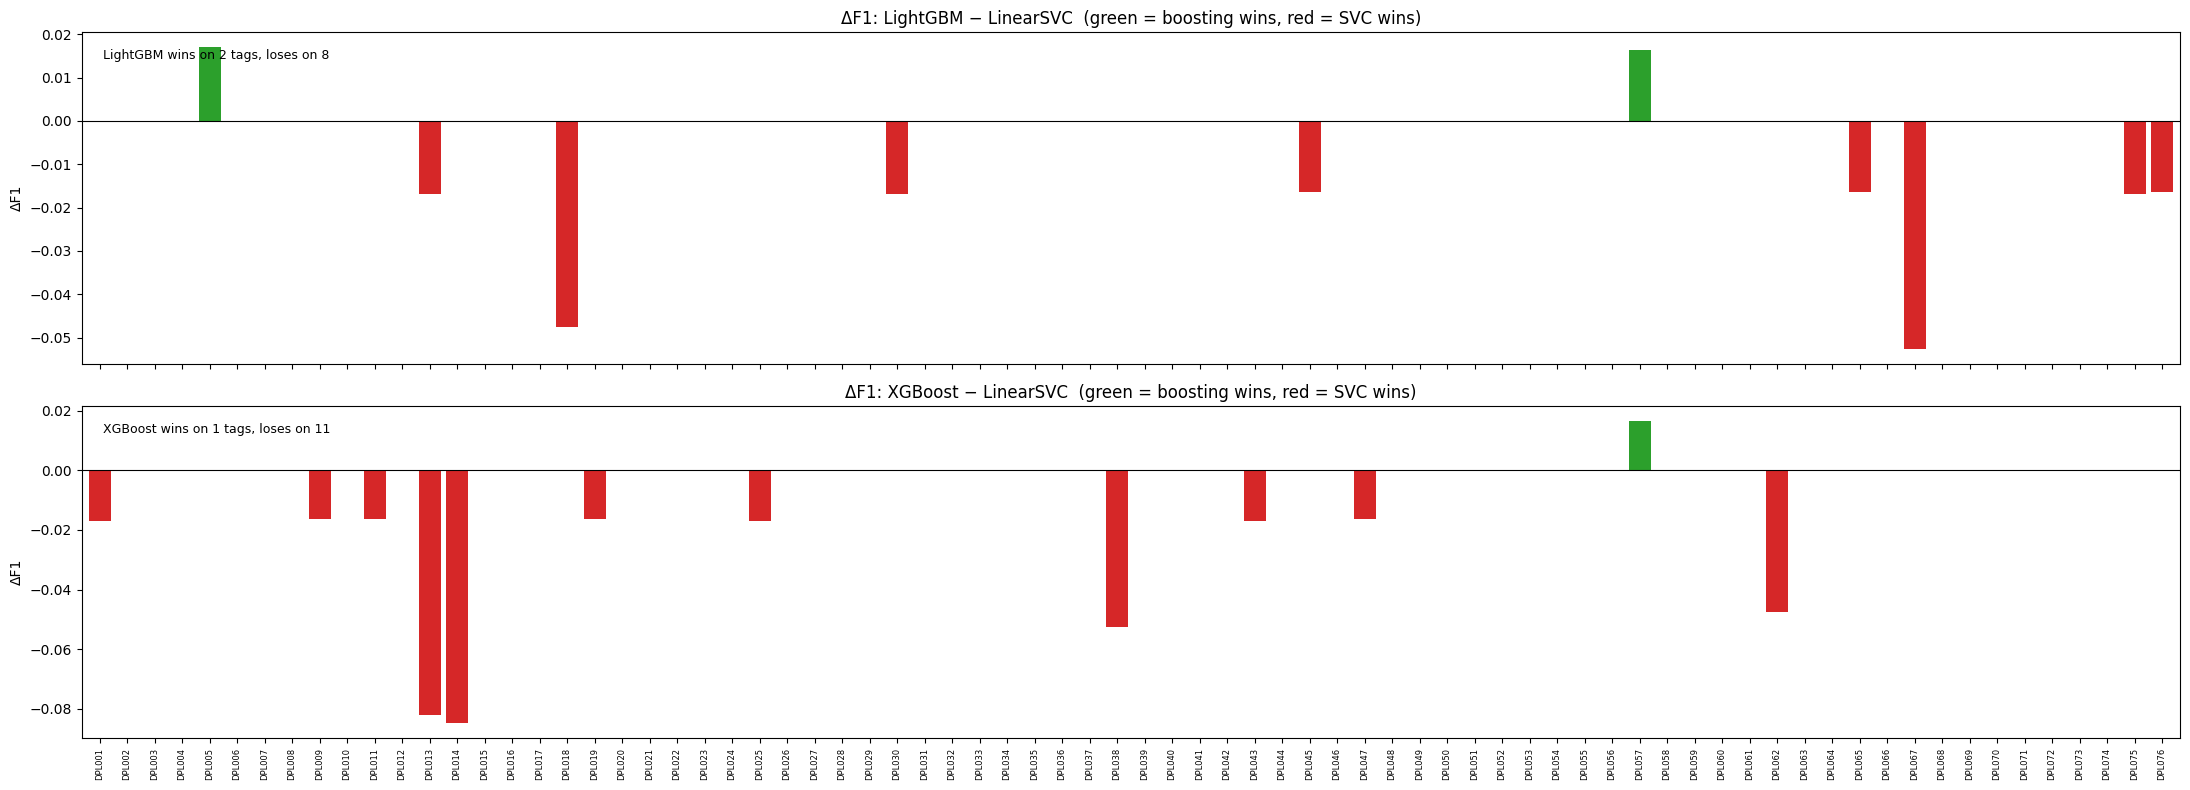

In [12]:
# Delta: LightGBM − LinearSVC and XGBoost − LinearSVC
fig, axes = plt.subplots(2, 1, figsize=(22, 8), sharex=True)

for ax, (name_a, name_b) in zip(axes, [
    ("LightGBM",  "LinearSVC"),
    ("XGBoost",   "LinearSVC"),
]):
    delta = per_class[name_a] - per_class[name_b]
    c = ["#2ca02c" if d > 0 else "#d62728" for d in delta.values]
    delta.plot(kind="bar", ax=ax, color=c, width=0.8)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"ΔF1: {name_a} − LinearSVC  (green = boosting wins, red = SVC wins)")
    ax.set_ylabel("ΔF1")
    ax.tick_params(axis="x", labelsize=6, rotation=90)
    wins  = (delta > 0).sum()
    loses = (delta < 0).sum()
    ax.text(0.01, 0.95, f"{name_a} wins on {wins} tags, loses on {loses}",
            transform=ax.transAxes, fontsize=9, va="top")

plt.tight_layout()
plt.show()

In [13]:
# Tags where ALL three models struggle (F1 < 0.80)
weak_all = [
    t for t in tag_names
    if all(per_class[m].get(t, 0) < 0.80 for m in results)
]
print(f"Tags below F1=0.80 in ALL three models ({len(weak_all)}):")
if weak_all:
    weak_df = pd.DataFrame(
        {m: [per_class[m].get(t, 0) for t in weak_all] for m in results},
        index=weak_all
    ).round(4)
    print(weak_df.to_string())
else:
    print("  None — all models exceed F1=0.80 on every tag.")

Tags below F1=0.80 in ALL three models (0):
  None — all models exceed F1=0.80 on every tag.


## 8. Confidence Scores

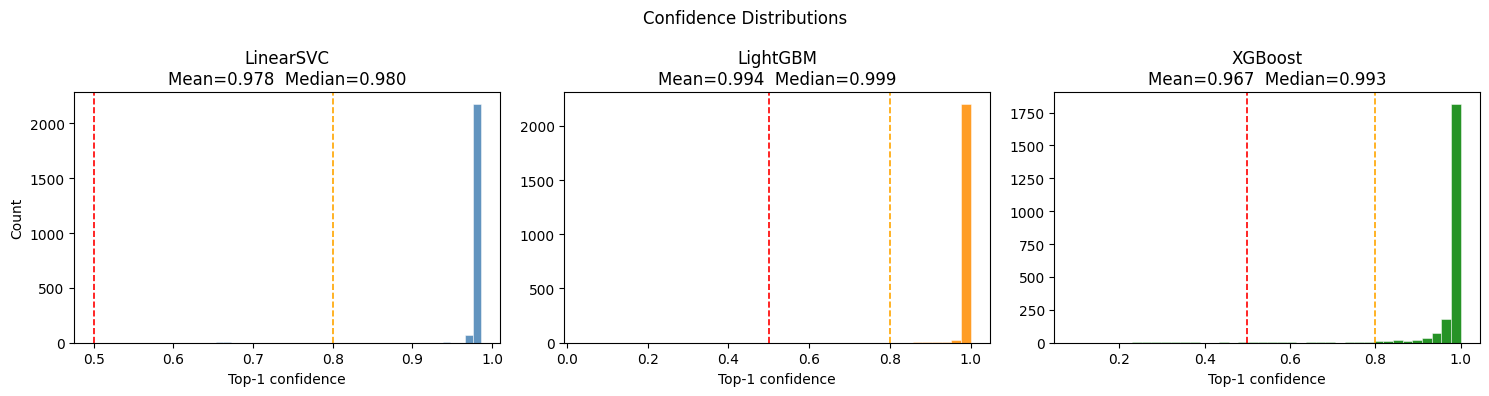

In [14]:
# Confidence distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, v), color in zip(axes, results.items(), colors):
    conf = v["conf"]
    ax.hist(conf, bins=40, color=color, edgecolor="white", linewidth=0.4, alpha=0.85)
    ax.axvline(0.50, color="red",    linestyle="--", linewidth=1.2)
    ax.axvline(0.80, color="orange", linestyle="--", linewidth=1.2)
    ax.set_title(f"{name}\nMean={conf.mean():.3f}  Median={np.median(conf):.3f}")
    ax.set_xlabel("Top-1 confidence")

axes[0].set_ylabel("Count")
plt.suptitle("Confidence Distributions")
plt.tight_layout()
plt.show()

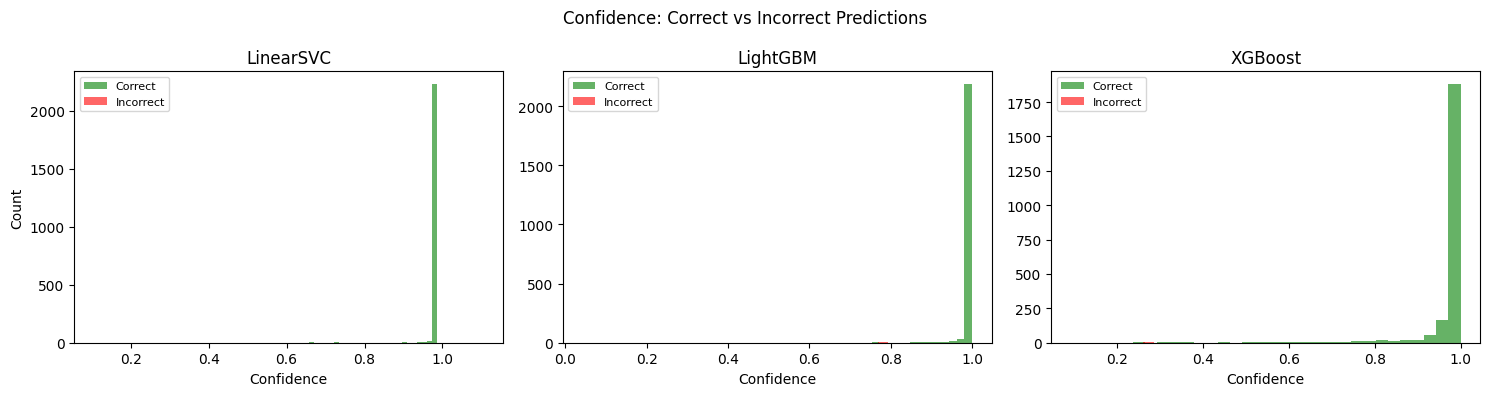

In [15]:
# Correct vs incorrect confidence
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, v), color in zip(axes, results.items(), colors):
    correct = v["preds"] == y_test
    ax.hist(v["conf"][correct],  bins=30, alpha=0.6, label="Correct",   color="green")
    ax.hist(v["conf"][~correct], bins=30, alpha=0.6, label="Incorrect", color="red")
    ax.set_title(name)
    ax.set_xlabel("Confidence")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Count")
plt.suptitle("Confidence: Correct vs Incorrect Predictions")
plt.tight_layout()
plt.show()

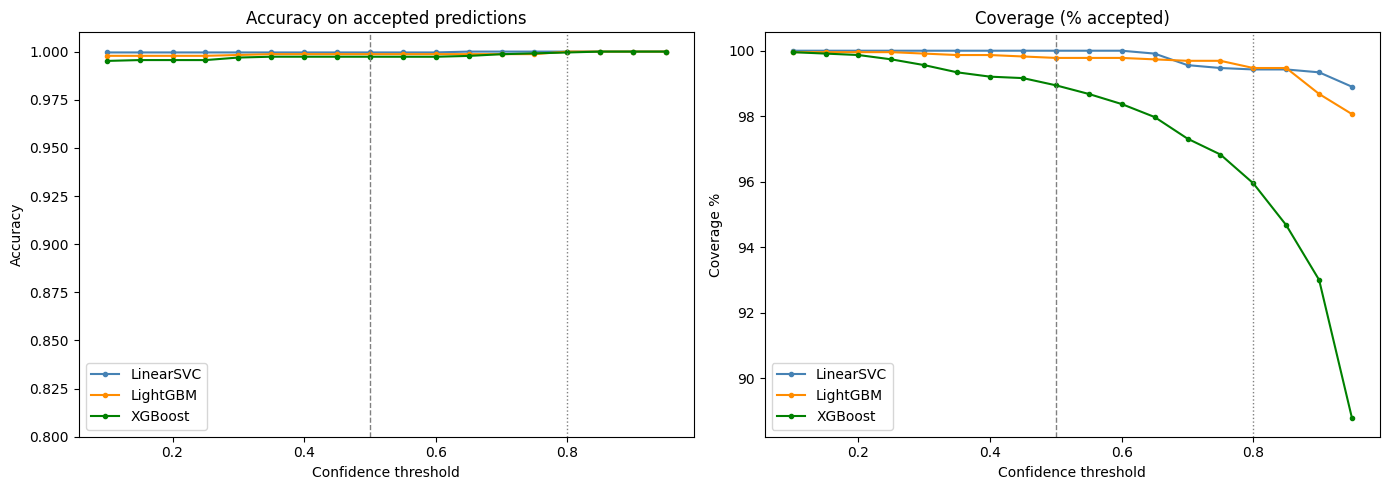

In [16]:
# Threshold analysis — accuracy vs coverage for all three
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
thresholds = np.arange(0.1, 1.0, 0.05)

for name, v, color in zip(results, results.values(), colors):
    conf   = v["conf"]
    preds  = v["preds"]
    accs, covs = [], []
    for t in thresholds:
        mask = conf >= t
        if mask.sum() == 0:
            break
        accs.append(accuracy_score(y_test[mask], preds[mask]))
        covs.append(mask.mean() * 100)

    ax1.plot(thresholds[:len(accs)], accs, "-o", color=color, markersize=3, label=name)
    ax2.plot(thresholds[:len(covs)], covs, "-o", color=color, markersize=3, label=name)

for ax in (ax1, ax2):
    ax.axvline(0.50, color="grey", linestyle="--", linewidth=1)
    ax.axvline(0.80, color="grey", linestyle=":",  linewidth=1)
    ax.legend()
    ax.set_xlabel("Confidence threshold")

ax1.set_title("Accuracy on accepted predictions")
ax1.set_ylabel("Accuracy"); ax1.set_ylim(0.8, 1.01)
ax2.set_title("Coverage (% accepted)")
ax2.set_ylabel("Coverage %")
plt.tight_layout()
plt.show()

## 9. Feature Importance

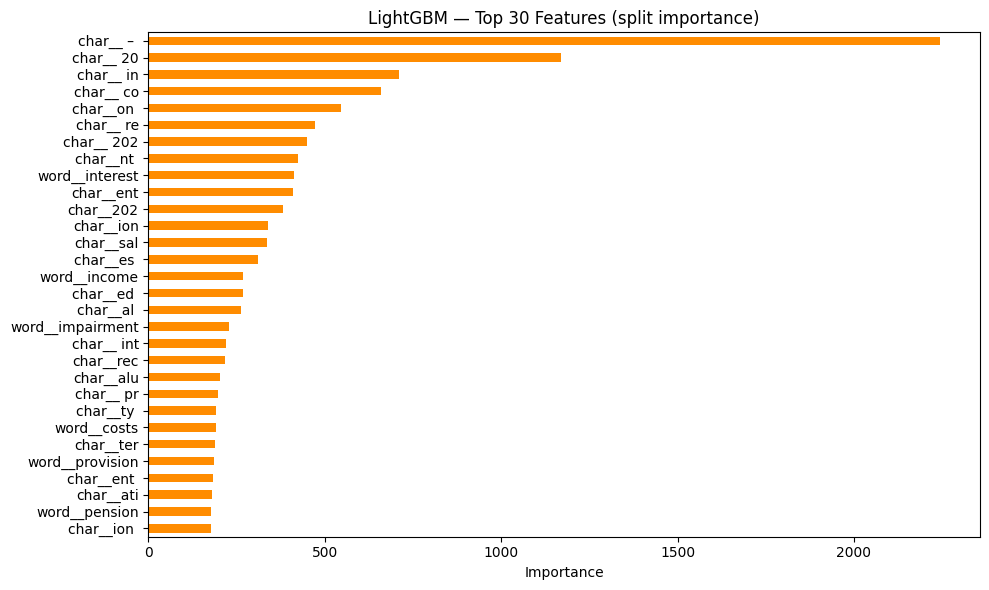

Top 30 features:
char__ –            2245
char__ 20           1169
char__ in            710
char__ co            659
char__on             545
char__ re            471
char__ 202           449
char__nt             425
word__interest       412
char__ent            411
char__202            382
char__ion            339
char__sal            335
char__es             310
word__income         269
char__ed             267
char__al             263
word__impairment     229
char__ int           219
char__rec            218
char__alu            202
char__ pr            197
char__ty             191
word__costs          191
char__ter            190
word__provision      185
char__ent            182
char__ati            180
word__pension        176
char__ion            176


In [17]:
# ── LightGBM: top features by split gain ─────────────────────────────────────
# Recover feature names from the TF-IDF FeatureUnion
word_features = tfidf.transformer_list[0][1].get_feature_names_out()
char_features = tfidf.transformer_list[1][1].get_feature_names_out()
feature_names = np.concatenate([
    [f"word__{f}" for f in word_features],
    [f"char__{f}" for f in char_features],
])

lgb_importance = pd.Series(
    lgb_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
top30 = lgb_importance.head(30)
top30.plot(kind="barh", ax=ax, color="darkorange")
ax.invert_yaxis()
ax.set_title("LightGBM — Top 30 Features (split importance)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("Top 30 features:")
print(top30.to_string())

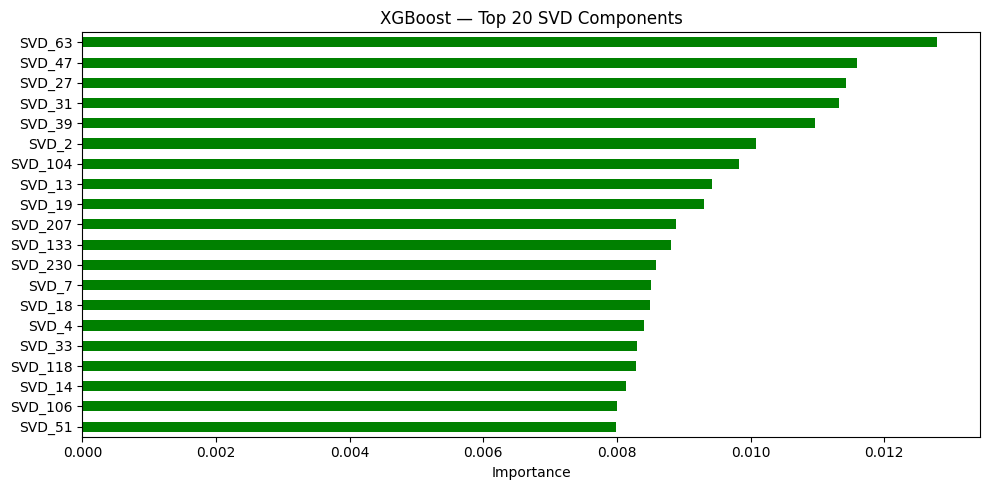

In [18]:
# ── XGBoost: top SVD components ──────────────────────────────────────────────
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=[f"SVD_{i}" for i in range(SVD_COMPONENTS)]
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 5))
xgb_importance.plot(kind="barh", ax=ax, color="green")
ax.invert_yaxis()
ax.set_title("XGBoost — Top 20 SVD Components")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

In [19]:
# ── Top words per DPL tag — LinearSVC coefficients ───────────────────────────
# Most informative words for each class according to the SVC weights
svc_inner  = svc_pipe.named_steps["clf"]

# CalibratedClassifierCV stores per-fold calibrators; use first calibrator's SVC
try:
    coef_matrix = np.mean(
        [cal.estimator.coef_ for cal in svc_inner.calibrated_classifiers_], axis=0
    )  # shape (n_classes, n_features)

    # Get sparse feature names from TF-IDF
    print("Top 5 discriminative words per DPL tag (LinearSVC weights):")
    print(f"{'Tag':<10} {'Top words'}")
    print("-" * 70)
    for class_idx, tag in enumerate(le.classes_):
        top_idx  = np.argsort(coef_matrix[class_idx])[::-1][:5]
        top_words = [feature_names[i].replace("word__", "").replace("char__", "[c]") for i in top_idx]
        print(f"{tag:<10} {', '.join(top_words)}")
except Exception as e:
    print(f"Could not extract coefficients: {e}")

Top 5 discriminative words per DPL tag (LinearSVC weights):
Tag        Top words
----------------------------------------------------------------------
DPL001     digital marketing services, marketing services, digital marketing, digital, agency
DPL002     amortisation, [c]mort, [c]morti, [c] amor, [c]amort
DPL003     tax advisory, tax advisory fees, audit, compliance services, vat compliance
DPL004     debt, debt impairment, debt impairment loss, trade receivable impairment, receivable impairment
DPL005     account, account maintenance, account maintenance fee, account charges, current account charges
DPL006     current account interest, account interest, account interest income, bank interest credited, interest
DPL007     donation to, donation, giving, fundraising, fundraising event
DPL008     cleaning, [c] clea, [c] cle, [c]clea, [c]lean
DPL009     operational consultancy, consulting services, management consulting, consultancy, transformation
DPL010     depreciation, depreciation c

## 10. Save Models

In [20]:
os.makedirs("models/lgbm",     exist_ok=True)
os.makedirs("models/xgboost",  exist_ok=True)
os.makedirs("models/svc_base", exist_ok=True)

label_map = {
    "id2label": {str(i): str(c) for i, c in enumerate(le.classes_)},
    "label2id": {str(c): int(i) for i, c in enumerate(le.classes_)},
}

# LightGBM
lgb_model.booster_.save_model("models/lgbm/model.txt")
joblib.dump(tfidf, "models/lgbm/tfidf.joblib")
joblib.dump(le,    "models/lgbm/label_encoder.joblib")
with open("models/lgbm/label_classes.json", "w") as f:
    json.dump(label_map, f, indent=2)

# XGBoost
xgb_model.save_model("models/xgboost/model.ubj")
joblib.dump(tfidf, "models/xgboost/tfidf.joblib")
joblib.dump(svd,   "models/xgboost/svd.joblib")
joblib.dump(le,    "models/xgboost/label_encoder.joblib")
with open("models/xgboost/label_classes.json", "w") as f:
    json.dump(label_map, f, indent=2)

# LinearSVC (baseline)
joblib.dump(svc_pipe, "models/svc_base/model.joblib")
joblib.dump(tfidf,    "models/svc_base/tfidf.joblib")
joblib.dump(le,       "models/svc_base/label_encoder.joblib")
with open("models/svc_base/label_classes.json", "w") as f:
    json.dump(label_map, f, indent=2)

# Summary metrics
metrics_out = {
    k: {
        "accuracy":        float(v["acc"]),
        "f1_weighted":     float(v["f1w"]),
        "f1_macro":        float(v["f1m"]),
        "train_time_s":    round(v["time"], 1),
        "mean_confidence": round(float(v["conf"].mean()), 4),
    }
    for k, v in results.items()
}
with open("models/boosting_comparison.json", "w") as f:
    json.dump(metrics_out, f, indent=2)

print("Models saved:")
print("  models/lgbm/model.txt")
print("  models/xgboost/model.ubj")
print("  models/svc_base/model.joblib")
print("  models/boosting_comparison.json")

Models saved:
  models/lgbm/model.txt
  models/xgboost/model.ubj
  models/svc_base/model.joblib
  models/boosting_comparison.json


## 11. Inference Helper

In [21]:
def predict_lgbm(descriptions: list[str], top_k: int = 3,
                 model_dir: str = "models/lgbm") -> list[dict]:
    _tfidf = joblib.load(f"{model_dir}/tfidf.joblib")
    _le    = joblib.load(f"{model_dir}/label_encoder.joblib")
    _model = lgb.Booster(model_file=f"{model_dir}/model.txt")

    X      = _tfidf.transform(descriptions)
    probs  = _model.predict(X)     # (n, 76)
    return [
        {
            "description": desc,
            "top_prediction": {"tag": _le.classes_[probs[i].argmax()],
                                "confidence": round(float(probs[i].max()), 4)},
            "top_k": [{"tag": _le.classes_[j],
                        "confidence": round(float(probs[i][j]), 4)}
                       for j in np.argsort(probs[i])[::-1][:top_k]],
        }
        for i, desc in enumerate(descriptions)
    ]


def predict_xgb(descriptions: list[str], top_k: int = 3,
                model_dir: str = "models/xgboost") -> list[dict]:
    _tfidf  = joblib.load(f"{model_dir}/tfidf.joblib")
    _svd    = joblib.load(f"{model_dir}/svd.joblib")
    _le     = joblib.load(f"{model_dir}/label_encoder.joblib")
    _model  = xgb.XGBClassifier()
    _model.load_model(f"{model_dir}/model.ubj")

    X      = _svd.transform(_tfidf.transform(descriptions))
    probs  = _model.predict_proba(X)
    return [
        {
            "description": desc,
            "top_prediction": {"tag": _le.classes_[probs[i].argmax()],
                                "confidence": round(float(probs[i].max()), 4)},
            "top_k": [{"tag": _le.classes_[j],
                        "confidence": round(float(probs[i][j]), 4)}
                       for j in np.argsort(probs[i])[::-1][:top_k]],
        }
        for i, desc in enumerate(descriptions)
    ]


# ── Test ─────────────────────────────────────────────────────────────────────
test_descs = [
    "INV-55234 – Deloitte audit services FY2025",
    "Monthly payroll – March 2026 – Finance",
    "Interest charged on HSBC overdraft – January",
    "Interest received on shareholder loan – April 2025",
    "Google Ads campaign – Q2 2026",
    "Office rent – London HQ – April 2026",
    "AWS cloud hosting – February subscription",
    "FX loss on USD settlement – AP-78341",
    "Goodwill impairment – Northern Division CGU – 2024",
    "Miscellaneous expense",
]

lgb_res = predict_lgbm(test_descs)
xgb_res = predict_xgb(test_descs)

print(f"{'Description':<50} {'LightGBM':<10} {'Conf':>6}  {'XGBoost':<10} {'Conf':>6}")
print("-" * 90)
for desc, lr, xr in zip(test_descs, lgb_res, xgb_res):
    lt = lr["top_prediction"]; xt = xr["top_prediction"]
    match = "✓" if lt["tag"] == xt["tag"] else "≠"
    print(f"{desc[:49]:<50} {lt['tag']:<10} {lt['confidence']:>6.3f}  "
          f"{xt['tag']:<10} {xt['confidence']:>6.3f}  {match}")

Description                                        LightGBM     Conf  XGBoost      Conf
------------------------------------------------------------------------------------------
INV-55234 – Deloitte audit services FY2025         DPL003      0.999  DPL003      0.985  ✓
Monthly payroll – March 2026 – Finance             DPL068      0.999  DPL068      0.612  ✓
Interest charged on HSBC overdraft – January       DPL035      0.999  DPL035      0.995  ✓
Interest received on shareholder loan – April 202  DPL075      0.998  DPL075      0.995  ✓
Google Ads campaign – Q2 2026                      DPL001      0.999  DPL001      0.996  ✓
Office rent – London HQ – April 2026               DPL055      0.998  DPL055      0.990  ✓
AWS cloud hosting – February subscription          DPL037      0.996  DPL037      0.984  ✓
FX loss on USD settlement – AP-78341               DPL043      1.000  DPL043      0.995  ✓
Goodwill impairment – Northern Division CGU – 202  DPL028      1.000  DPL028      0.997  ✓
Mi

---

## Summary

### Expected outcome for short financial text

TF-IDF + LinearSVC typically **outperforms** gradient boosting on short, structured text because:
- Linear models excel in high-dimensional sparse feature spaces
- Boosting gains come from feature interactions — less relevant for keyword-based accounting descriptions
- LightGBM often closes the gap because it can handle sparse matrices natively

### When boosting wins
- If you add **numeric features** (amount, date, document type) alongside text → XGBoost/LightGBM shine
- If you use **dense embeddings** (DistilBERT sentence vectors) as input → boosting > linear models

### Feature pipeline per model

| Model | Features | Notes |
|---|---|---|
| LinearSVC | Sparse TF-IDF (80k dims) | Native sparse support |
| LightGBM | Sparse TF-IDF (80k dims) | Native sparse support |
| XGBoost | Dense SVD (300 dims) | TruncatedSVD reduces memory + improves convergence |

### Next step — combine models
Use the probability outputs from all three in a **stacking ensemble**:  
feed `[svc_probs, lgb_probs, xgb_probs]` into a final LogisticRegression meta-learner.